<a href="https://colab.research.google.com/github/Aryan-Gupta2002/Deep-Learning---Tensorflow/blob/main/Instance_Segmentation_MaskRCNN_PR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PyTorch version: 2.10.0+cpu
TorchVision version: 0.25.0+cpu
Using device: cpu

[INFO] Loading pre-trained Mask R-CNN model...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 150MB/s]


[INFO] Model loaded successfully!

  Processing: People on Street
[INFO] Image size: (640, 360)
[INFO] Detected 10 instances (threshold=0.7)

[RESULTS TABLE]
#    Class                Confidence   BBox
------------------------------------------------------------
1    person               0.9956      [14,177,268,350]
2    person               0.9954      [460,178,640,353]
3    person               0.9807      [189,190,288,347]
4    person               0.9731      [2,179,111,348]
5    person               0.9623      [376,185,520,348]
6    person               0.9396      [261,179,434,349]
7    handbag              0.8896      [276,227,329,328]
8    person               0.8319      [335,186,463,350]
9    person               0.8141      [554,181,639,347]
10   handbag              0.7269      [279,273,325,326]


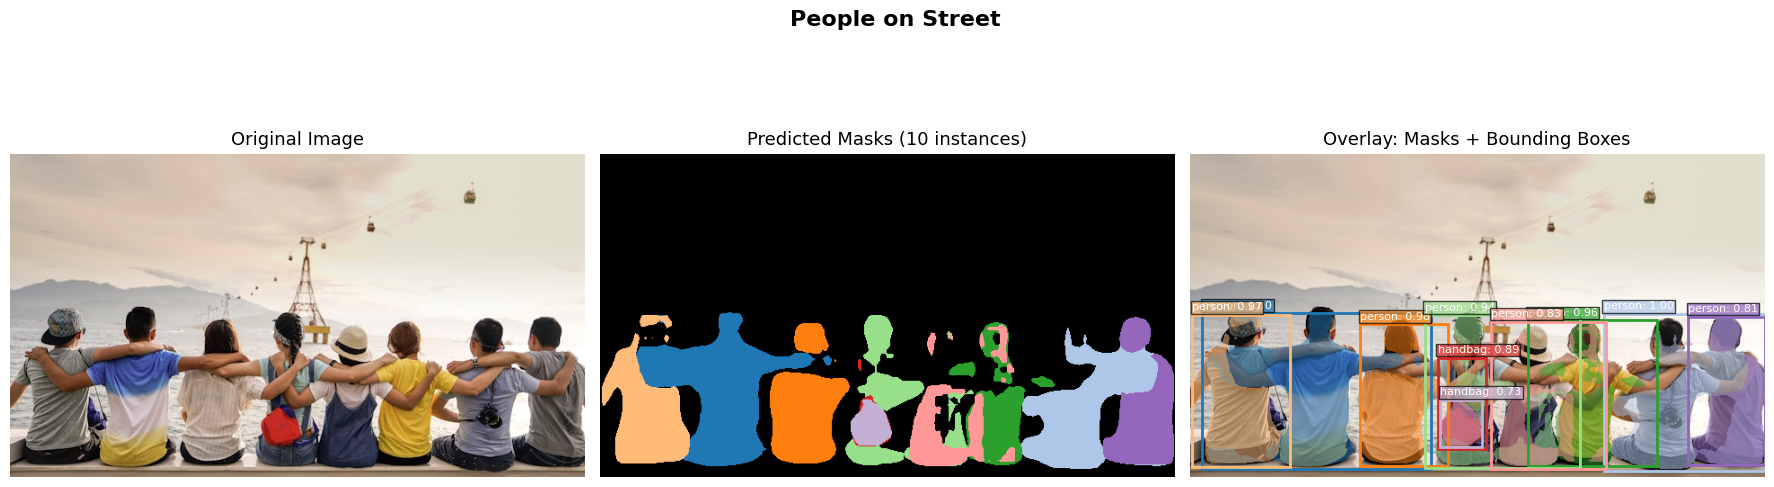

[INFO] Result saved!

[METRIC] IoU between instance 1 & 2: 0.0000

  Processing: Synthetic Shapes
[INFO] Image size: (640, 480)
[INFO] Detected 6 instances (threshold=0.5)

[RESULTS TABLE]
#    Class                Confidence   BBox
------------------------------------------------------------
1    kite                 0.9915      [375,312,471,445]
2    kite                 0.9691      [154,144,254,239]
3    kite                 0.9601      [149,289,235,398]
4    kite                 0.9504      [355,87,444,205]
5    kite                 0.9357      [47,45,139,153]
6    frisbee              0.5033      [355,85,441,203]


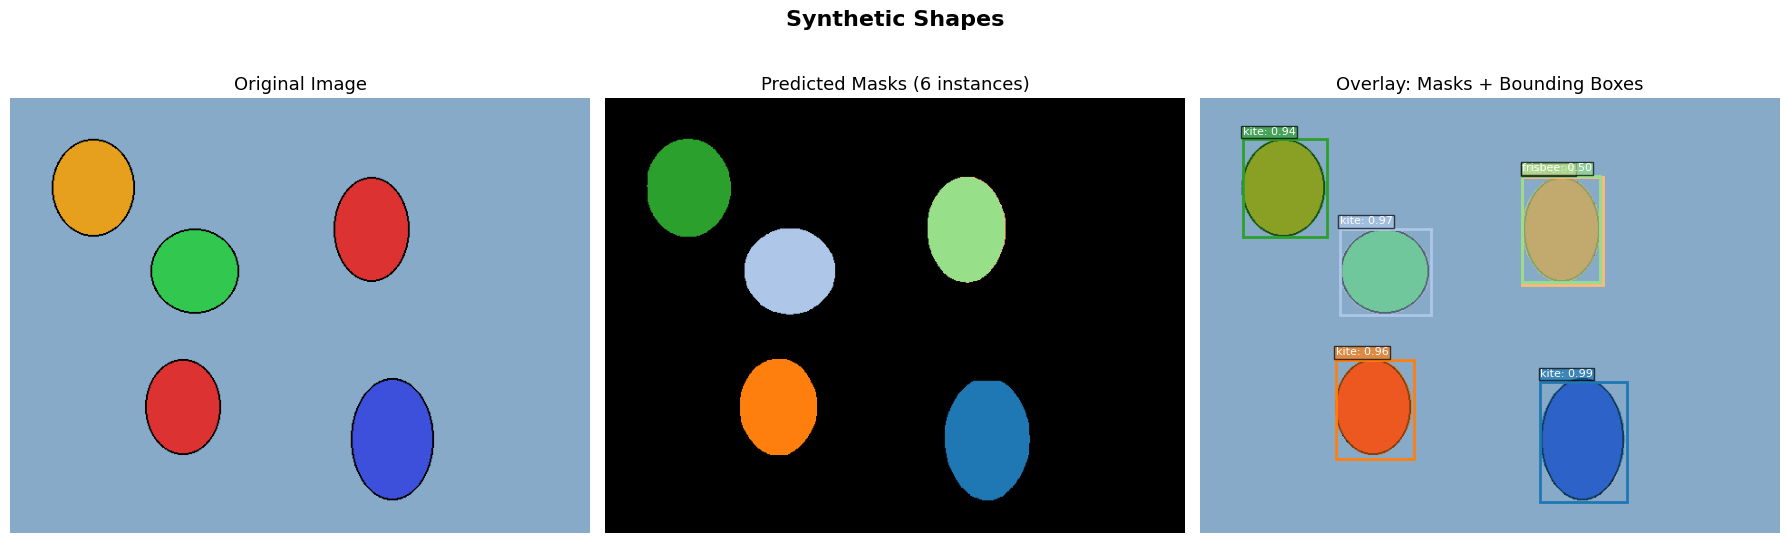

[INFO] Result saved!

[METRIC] IoU between instance 1 & 2: 0.0000

  Processing: Animals
[INFO] Image size: (640, 426)
[INFO] Detected 1 instances (threshold=0.6)

[RESULTS TABLE]
#    Class                Confidence   BBox
------------------------------------------------------------
1    dog                  0.9619      [106,33,501,417]


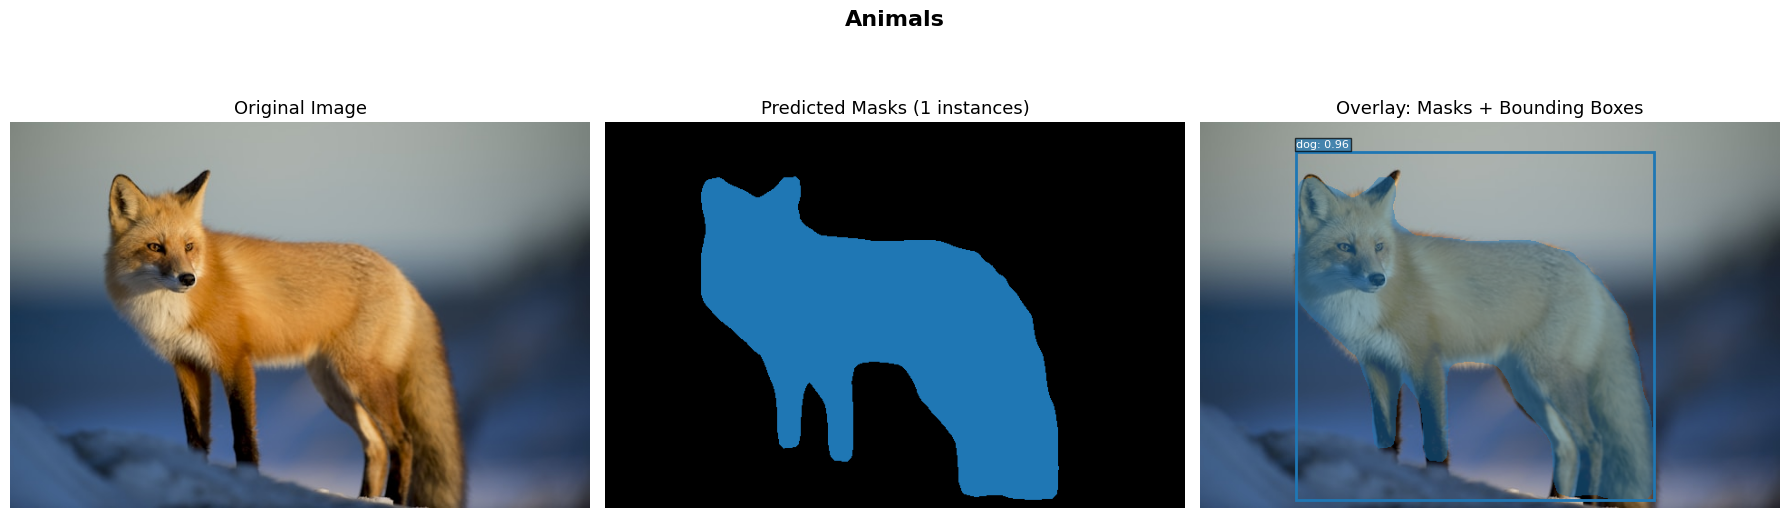

[INFO] Result saved!


In [ ]:
# ============================================================
# Experiment 7: Instance Segmentation using Mask R-CNN
# ============================================================

# ── STEP 1: Import Libraries ──────────────────────────────
import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import maskrcnn_resnet50_fpn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import requests
from io import BytesIO
import random
import os

print("PyTorch version:", torch.__version__)
print("TorchVision version:", torchvision.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ── STEP 2: COCO Class Labels (80 classes) ────────────────
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle',
    'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
    'fire hydrant', 'N/A', 'stop sign', 'parking meter', 'bench',
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant',
    'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella',
    'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat',
    'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli',
    'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A',
    'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink',
    'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]

# ── STEP 3: Load Pre-trained Mask R-CNN Model ─────────────
print("\n[INFO] Loading pre-trained Mask R-CNN model...")
model = maskrcnn_resnet50_fpn(pretrained=True)
model.eval()
model.to(device)
print("[INFO] Model loaded successfully!")

# ── STEP 4: Image Loading Utility ─────────────────────────
def load_image_from_url(url):
    """URL se image load karo"""
    try:
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        return img
    except Exception as e:
        print(f"[WARNING] Could not load from URL: {e}")
        return None

def create_synthetic_image(width=640, height=480, num_objects=3):
    from PIL import ImageDraw
    img = Image.new("RGB", (width, height), color=(135, 170, 200))
    draw = ImageDraw.Draw(img)
    colors = [(220, 50, 50), (50, 200, 80), (60, 80, 220), (230, 160, 30)]
    random.seed(42)
    for i in range(num_objects):
        x1 = random.randint(30, width - 130)
        y1 = random.randint(30, height - 130)
        x2 = x1 + random.randint(80, 150)
        y2 = y1 + random.randint(80, 150)
        c = colors[i % len(colors)]
        draw.ellipse([x1, y1, x2, y2], fill=c, outline=(0, 0, 0), width=2)
    return img

# ── STEP 5: Sample Images Dataset ─────────────────────────
SAMPLE_IMAGES = {
    "Street Scene": "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png",
    "People": "https://images.unsplash.com/photo-1529156069898-49953e39b3ac?w=640",
    "Animals": "https://images.unsplash.com/photo-1474511320723-9a56873867b5?w=640",
    "Traffic":  "https://images.unsplash.com/photo-1494976388531-d1058494cdd8?w=640",
}

# ── STEP 6: Preprocessing ─────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
])

def preprocess_image(img):
    img_tensor = transform(img)
    return img_tensor.unsqueeze(0).to(device)

# ── STEP 7: Post-processing & Prediction ──────────────────
def get_predictions(img, threshold=0.7):

    img_tensor = preprocess_image(img)
    with torch.no_grad():
        predictions = model(img_tensor)
    pred = predictions[0]

    # Filter by threshold
    scores = pred['scores'].cpu().numpy()
    keep = scores >= threshold

    boxes  = pred['boxes'][keep].cpu().numpy()
    labels = pred['labels'][keep].cpu().numpy()
    scores = scores[keep]
    masks  = pred['masks'][keep].cpu().numpy()  # shape: [N, 1, H, W]

    return boxes, labels, scores, masks

# ── STEP 8: Visualization ─────────────────────────────────
COLORS = plt.cm.tab20.colors  # 20 distinct colors

def visualize_predictions(img, boxes, labels, scores, masks,
                           title="Instance Segmentation Result"):

    img_np = np.array(img).copy()
    overlay = img_np.copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # --- Panel 1: Original Image ---
    axes[0].imshow(img_np)
    axes[0].set_title("Original Image", fontsize=13)
    axes[0].axis('off')

    # --- Panel 2: Masks Only ---
    mask_canvas = np.zeros_like(img_np)
    for i, mask in enumerate(masks):
        color = [int(c * 255) for c in COLORS[i % len(COLORS)][:3]]
        m = mask[0] > 0.5
        mask_canvas[m] = color
    axes[1].imshow(mask_canvas)
    axes[1].set_title(f"Predicted Masks ({len(masks)} instances)", fontsize=13)
    axes[1].axis('off')

    # --- Panel 3: Overlay (Image + Masks + Boxes) ---
    for i, mask in enumerate(masks):
        color = [int(c * 255) for c in COLORS[i % len(COLORS)][:3]]
        m = mask[0] > 0.5
        overlay[m] = (np.array(color) * 0.5 + overlay[m] * 0.5).astype(np.uint8)

    axes[2].imshow(overlay)

    for i, (box, label, score) in enumerate(zip(boxes, labels, scores)):
        color = COLORS[i % len(COLORS)]
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        axes[2].add_patch(rect)
        class_name = COCO_INSTANCE_CATEGORY_NAMES[label]
        axes[2].text(
            x1, y1 - 5,
            f"{class_name}: {score:.2f}",
            color='white', fontsize=8,
            bbox=dict(facecolor=color, alpha=0.7, pad=1)
        )

    axes[2].set_title("Overlay: Masks + Bounding Boxes", fontsize=13)
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(f"result_{title.replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[INFO] Result saved!")

# ── STEP 9: Compute IoU ───────────────────────────────────
def compute_iou(mask1, mask2):           #intersection over union
    m1 = mask1 > 0.5
    m2 = mask2 > 0.5
    intersection = np.logical_and(m1, m2).sum()
    union        = np.logical_or(m1, m2).sum()
    if union == 0:
        return 0.0
    return float(intersection) / float(union)

# ── STEP 10: Main Experiment Runner ───────────────────────
def run_experiment(image_source, name="Test", threshold=0.7):
    print(f"\n{'='*55}")
    print(f"  Processing: {name}")
    print(f"{'='*55}")

    # Load image
    if isinstance(image_source, str):          # URL
        img = load_image_from_url(image_source)
        if img is None:
            print("[INFO] Falling back to synthetic image...")
            img = create_synthetic_image()
    else:                                       # PIL Image directly
        img = image_source

    print(f"[INFO] Image size: {img.size}")

    # Get predictions
    boxes, labels, scores, masks = get_predictions(img, threshold)
    print(f"[INFO] Detected {len(boxes)} instances (threshold={threshold})")

    if len(boxes) == 0:
        print("[WARNING] No objects detected. Try lowering threshold.")
        return

    # Print details
    print("\n[RESULTS TABLE]")
    print(f"{'#':<4} {'Class':<20} {'Confidence':<12} {'BBox'}")
    print("-" * 60)
    for i, (box, label, score) in enumerate(zip(boxes, labels, scores)):
        class_name = COCO_INSTANCE_CATEGORY_NAMES[label]
        print(f"{i+1:<4} {class_name:<20} {score:.4f}      "
              f"[{box[0]:.0f},{box[1]:.0f},{box[2]:.0f},{box[3]:.0f}]")

    # Visualize
    visualize_predictions(img, boxes, labels, scores, masks, title=name)

    # IoU between first two masks (if available)
    if len(masks) >= 2:
        iou = compute_iou(masks[0][0], masks[1][0])
        print(f"\n[METRIC] IoU between instance 1 & 2: {iou:.4f}")

    return boxes, labels, scores, masks

# ── STEP 11: Run on Multiple Images ───────────────────────
if __name__ == "__main__":

    # Test Image 1 – from URL
    run_experiment(
        "https://images.unsplash.com/photo-1529156069898-49953e39b3ac?w=640",
        name="People on Street",
        threshold=0.7
    )

    # Test Image 2 – Synthetic fallback always works
    synthetic = create_synthetic_image(640, 480, num_objects=5)
    run_experiment(synthetic, name="Synthetic Shapes", threshold=0.5)

    # Test Image 3 – Animals
    run_experiment(
        "https://images.unsplash.com/photo-1474511320723-9a56873867b5?w=640",
        name="Animals",
        threshold=0.6
    )

# ── BONUS: Upload your own image in Colab ─────────────────
# from google.colab import files
# uploaded = files.upload()
# img_path = list(uploaded.keys())[0]
# img = Image.open(img_path).convert("RGB")
# run_experiment(img, name="My Custom Image", threshold=0.5)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


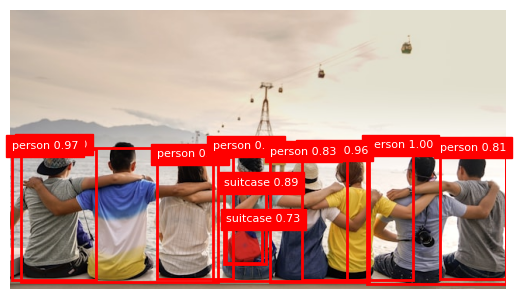

In [ ]:
# Torch library import (AI model chalane ke liye)
import torch

# Torchvision (ready-made models ke liye)
import torchvision

# Image ko tensor me convert karne ke liye
from torchvision import transforms

# Mask R-CNN model import
from torchvision.models.detection import maskrcnn_resnet50_fpn

# Maths operations ke liye
import numpy as np

# Image display karne ke liye
import matplotlib.pyplot as plt

# Image handling ke liye
from PIL import Image

# Internet se image load karne ke liye
import requests

# Image data ko memory me handle karne ke liye
from io import BytesIO

# Random shapes banane ke liye
import random


# Check karta hai GPU available hai ya nahi
# Agar hai to GPU use karega, warna CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# COCO dataset ke object names (labels)
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle',
    'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
    'fire hydrant', 'N/A', 'stop sign', 'parking meter', 'bench',
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant',
    'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat',
    'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli',
    'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink',
    'refrigerator', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]


# Pre-trained Mask R-CNN model load kar raha hai
model = maskrcnn_resnet50_fpn(pretrained=True)

# Model ko evaluation mode me daal rahe (training nahi karega)
model.eval()

# Model ko GPU/CPU par shift kar rahe
model.to(device)


# Function: URL se image load karega
def load_image(url):
    try:
        # URL se data download kar raha hai
        response = requests.get(url)

        # Image open kar raha aur RGB me convert kar raha
        img = Image.open(BytesIO(response.content)).convert("RGB")

        # Image return
        return img
    except:
        # Error aaye to None return
        return None


# Function: agar internet na ho to fake image banaega
def create_image():
    from PIL import ImageDraw

    # Blank image bana rahe (size 640x480)
    img = Image.new("RGB", (640, 480), (135, 170, 200))

    # Drawing tool
    draw = ImageDraw.Draw(img)

    # 3 random circles draw karenge
    for _ in range(3):
        # Random position generate
        x1, y1 = random.randint(30, 400), random.randint(30, 300)

        # Shape ka size fix
        x2, y2 = x1 + 100, y1 + 100

        # Circle draw kar rahe
        draw.ellipse([x1, y1, x2, y2], fill=(255, 0, 0))

    return img


# Image ko tensor me convert karega
transform = transforms.ToTensor()


# Function: prediction karega
def predict(img, threshold=0.7):

    # Image ko tensor banake model ke format me la rahe
    img = transform(img).unsqueeze(0).to(device)

    # Gradient calculation off (fast inference ke liye)
    with torch.no_grad():
        pred = model(img)[0]

    # Confidence score check kar rahe
    keep = pred['scores'].cpu().numpy() >= threshold

    # Sirf high confidence results return kar rahe
    return (
        pred['boxes'][keep].cpu().numpy(),   # bounding boxes
        pred['labels'][keep].cpu().numpy(),  # object labels
        pred['scores'][keep].cpu().numpy(),  # confidence scores
        pred['masks'][keep].cpu().numpy()    # object masks
    )


# Function: result show karega
def show(img, boxes, labels, scores):

    # Image display kar rahe
    plt.imshow(img)

    # Har detected object ke liye loop
    for box, label, score in zip(boxes, labels, scores):

        # Box coordinates nikal rahe
        x1, y1, x2, y2 = box

        # Rectangle draw kar rahe
        plt.gca().add_patch(
            plt.Rectangle((x1, y1), x2-x1, y2-y1,
                          fill=False, edgecolor='red', linewidth=2)
        )

        # Label + confidence show kar rahe
        plt.text(x1, y1,
                 f"{COCO_INSTANCE_CATEGORY_NAMES[label]} {score:.2f}",
                 color='white', fontsize=8, backgroundcolor='red')

    # Axis hide
    plt.axis('off')

    # Final image show
    plt.show()


# Image URL
url = "https://images.unsplash.com/photo-1529156069898-49953e39b3ac?w=640"

# Image load (agar fail ho to synthetic banaega)
img = load_image(url) or create_image()

# Prediction run
boxes, labels, scores, masks = predict(img)

# Result show
show(img, boxes, labels, scores)